In [1]:
!pip install -q kagglehub gradio

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset downloaded to:")
print(path)

print("\nFiles/Folders:")
print(os.listdir(path))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset downloaded to:
/kaggle/input/intel-image-classification

Files/Folders:
['seg_train', 'seg_pred', 'seg_test']


In [4]:
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

print("Training folder:", train_dir)
print("Testing folder:", test_dir)

print("\nTraining Classes:")
print(os.listdir(train_dir))

Training folder: /kaggle/input/intel-image-classification/seg_train/seg_train
Testing folder: /kaggle/input/intel-image-classification/seg_test/seg_test

Training Classes:
['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']


In [5]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nNumber of classes:", train_generator.num_classes)
print("Class names:", train_generator.class_indices)
print("\nStep 5 completed!")

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Number of classes: 6
Class names: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}

Step 5 completed!


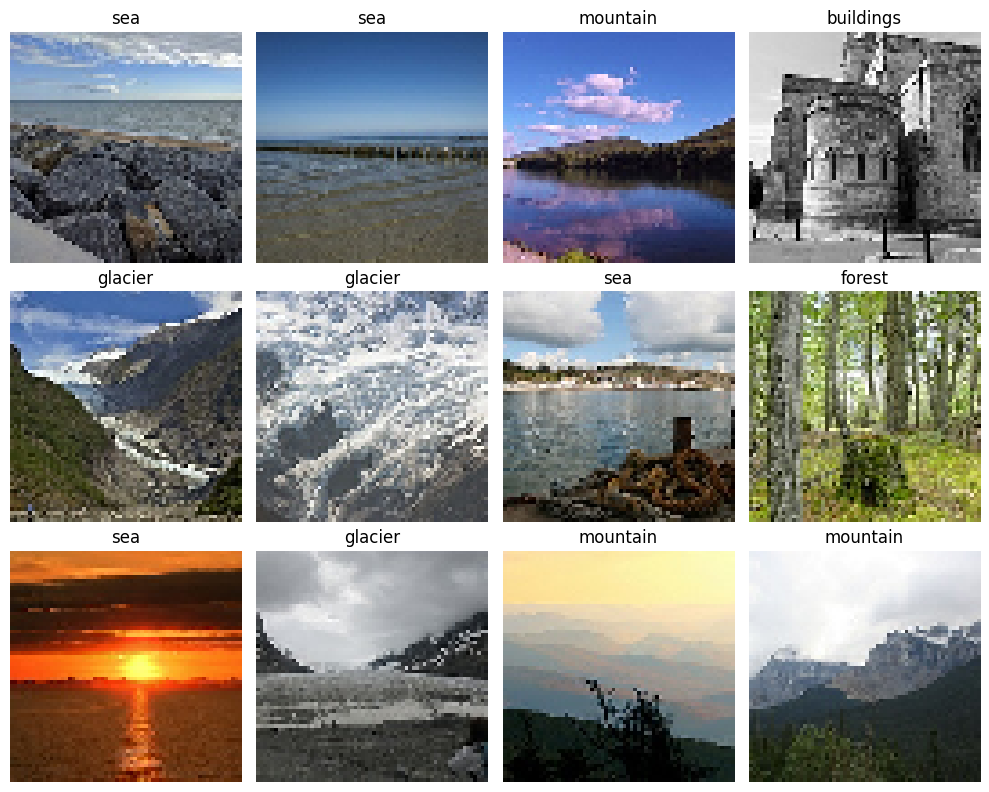

In [6]:
images, labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
NUM_CLASSES = 6

ann_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # Convert the 64x64 image into a 1D vector
    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

ann_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,966 (24.63 MB)

 Trainable params: 6,456,966 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 10

ann_history = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 200ms/step - accuracy: 0.3026 - loss: 1.8478 - val_accuracy: 0.4540 - val_loss: 1.4289
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.3449 - loss: 1.5386 - val_accuracy: 0.4269 - val_loss: 1.4252
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.3895 - loss: 1.4726 - val_accuracy: 0.4469 - val_loss: 1.4437
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.3949 - loss: 1.4571 - val_accuracy: 0.4864 - val_loss: 1.3507
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.4022 - loss: 1.4456 - val_accuracy: 0.4925 - val_loss: 1.3630
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.4155 - loss: 1.4308 - val_accuracy: 0.4700 - val_loss: 1.4098
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.4305 - loss: 1.3980 - val_accuracy: 0.5111 - val_loss: 1.3512
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.4339 - loss: 1.3934 -

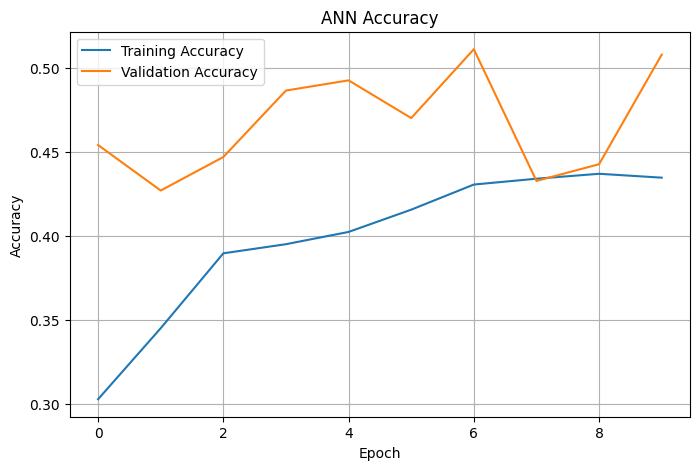

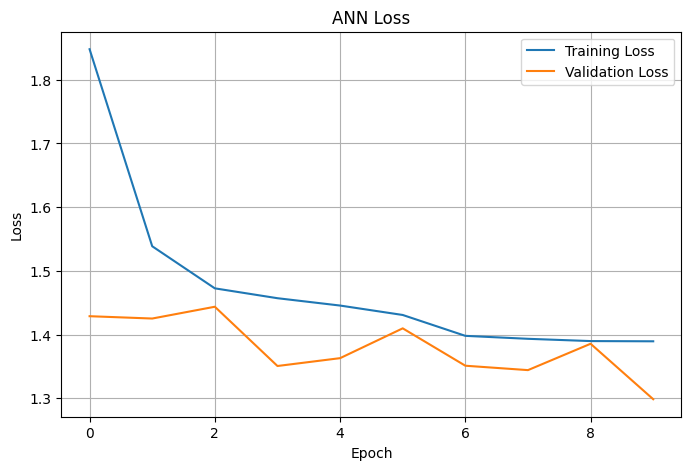

In [9]:
# ANN Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(ann_history.history["accuracy"], label="Training Accuracy")
plt.plot(ann_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# ANN Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(ann_history.history["loss"], label="Training Loss")
plt.plot(ann_history.history["val_loss"], label="Validation Loss")

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(test_generator)

print("\n===== ANN TEST RESULTS =====")
print(f"ANN Test Accuracy: {ann_test_accuracy * 100:.2f}%")
print(f"ANN Test Loss: {ann_test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.4950 - loss: 1.3205

===== ANN TEST RESULTS =====
ANN Test Accuracy: 49.50%
ANN Test Loss: 1.3205


In [11]:
cnn_model = models.Sequential([

    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(6, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,974 (2.61 MB)

 Trainable params: 683,974 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
CNN_EPOCHS = 10

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=CNN_EPOCHS
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 183ms/step - accuracy: 0.5337 - loss: 1.1598 - val_accuracy: 0.6623 - val_loss: 0.8741
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.6634 - loss: 0.8901 - val_accuracy: 0.7247 - val_loss: 0.7729
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.7333 - loss: 0.7446 - val_accuracy: 0.7682 - val_loss: 0.6572
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step - accuracy: 0.7589 - loss: 0.6666 - val_accuracy: 0.7978 - val_loss: 0.5976
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.7874 - loss: 0.5945 - val_accuracy: 0.7835 - val_loss: 0.6006
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 55s 155ms/step - accuracy: 0.8121 - loss: 0.5375 - val_accuracy: 0.7978 - val_loss: 0.5671
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.8284 - loss: 0.4902 - val_accuracy: 0.8049 - val_loss: 0.5748
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 155ms/step - accuracy: 0.8343 - loss: 0

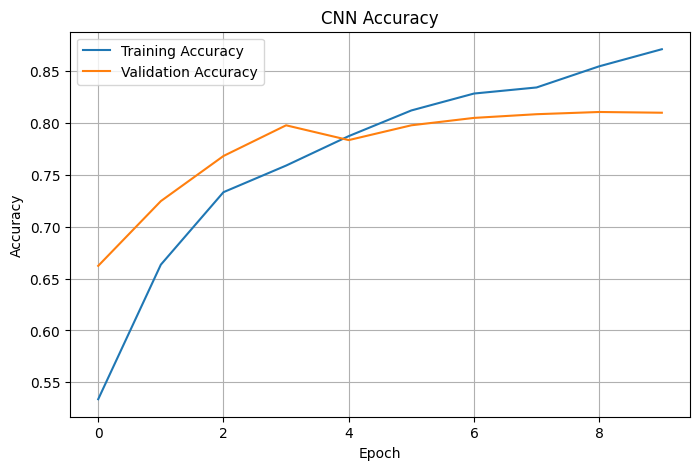

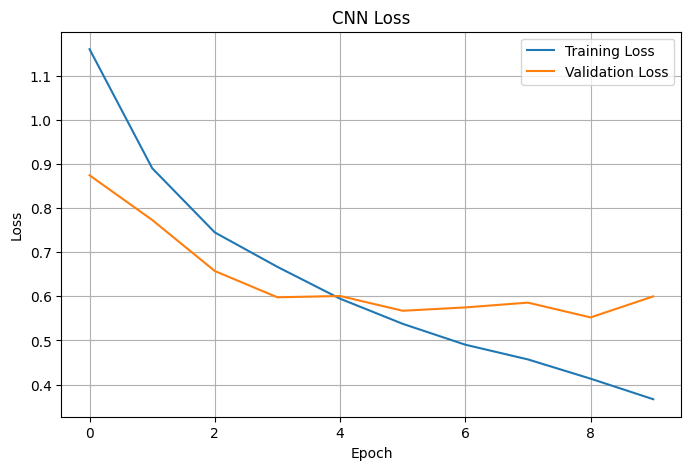

In [13]:
# CNN Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# CNN Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_generator)

print("\n===== CNN TEST RESULTS =====")
print(f"CNN Test Accuracy: {cnn_test_accuracy * 100:.2f}%")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8090 - loss: 0.5867

===== CNN TEST RESULTS =====
CNN Test Accuracy: 80.90%
CNN Test Loss: 0.5867


In [15]:
print("========== ANN vs CNN COMPARISON ==========")

print(f"ANN Test Accuracy : {ann_test_accuracy * 100:.2f}%")
print(f"ANN Test Loss     : {ann_test_loss:.4f}")

print(f"\nCNN Test Accuracy : {cnn_test_accuracy * 100:.2f}%")
print(f"CNN Test Loss     : {cnn_test_loss:.4f}")

print("\nBest Performing Model: CNN")
print(f"Accuracy Improvement: {(cnn_test_accuracy - ann_test_accuracy) * 100:.2f} percentage points")

========== ANN vs CNN COMPARISON ==========
ANN Test Accuracy : 49.50%
ANN Test Loss     : 1.3205

CNN Test Accuracy : 80.90%
CNN Test Loss     : 0.5867

Best Performing Model: CNN
Accuracy Improvement: 31.40 percentage points


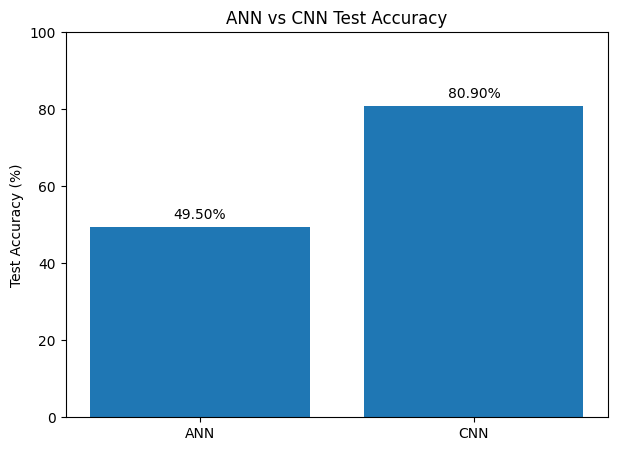

In [16]:
model_names = ["ANN", "CNN"]

accuracies = [
    ann_test_accuracy * 100,
    cnn_test_accuracy * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(model_names, accuracies)

plt.title("ANN vs CNN Test Accuracy")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

In [17]:
cnn_model.save("best_scene_classifier.keras")

print("CNN model saved successfully!")
print("File name: best_scene_classifier.keras")

CNN model saved successfully!
File name: best_scene_classifier.keras


In [18]:
import gradio as gr
from PIL import Image

# Classes in the same order used during training
class_names = list(train_generator.class_indices.keys())

print("Classes:", class_names)

def predict_image(image):

    # Resize to same size used for training
    image = image.convert("RGB")
    image = image.resize((64, 64))

    # Convert image to numpy array
    image = np.array(image).astype("float32")

    # Normalize
    image = image / 255.0

    # Add batch dimension
    image = np.expand_dims(image, axis=0)

    # CNN prediction
    prediction = cnn_model.predict(image, verbose=0)[0]

    # Return confidence for every class
    results = {
        class_names[i]: float(prediction[i])
        for i in range(len(class_names))
    }

    return results


demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=6),
    title="CNN Scene Image Classifier",
    description="Upload an image to classify it as Buildings, Forest, Glacier, Mountain, Sea or Street."
)

demo.launch()

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ed3c9bd3f3fffe668.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
ann_model.save("ann_model.keras")

print("ANN model saved successfully!")
print("File name: ann_model.keras")

ANN model saved successfully!
File name: ann_model.keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')